# Temporal Convolutional Network (TCN)

**Docker image**: `ml4t-gpu`

This notebook implements a Temporal Convolutional Network for predicting
forward returns on ETFs. TCNs use dilated causal convolutions to capture
long-range temporal dependencies without the sequential bottleneck of
recurrent networks.

**Learning Objectives**:
- Implement causal convolutions that prevent information leakage from the future
- Build a TCN with exponentially growing dilations (1, 2, 4, 8) for efficient
  receptive field coverage
- Understand the tradeoff between receptive field size and model depth
- Compare TCN predictions against a Ridge regression baseline

**Book Reference**: Chapter 13, Section 13.6 (The Full Practitioner Toolkit)

**Prerequisites**: ETF features (`case_studies/etfs/`)

In [1]:
"""Build a TCN with dilated causal convolutions for return prediction."""

import os
import warnings

os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

import numpy as np
import plotly.graph_objects as go
import polars as pl
import torch
import torch.nn as nn
from ml4t.diagnostic.metrics import cross_sectional_ic_series
from plotly.subplots import make_subplots
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from torch.nn.utils.parametrizations import weight_norm

from utils.reproducibility import set_global_seeds
from utils.style import COLORS

warnings.filterwarnings("ignore")

from dl_sequences import create_sequences_multi_asset, load_dl_dataset, train_model

In [2]:
SEED = 42
EPOCHS = 30
LOOKBACK = 60
BATCH_SIZE = 128
N_CHANNELS = 32
KERNEL_SIZE = 3
DROPOUT = 0.1
LR = 1e-3
LABEL_HORIZON = 21

In [3]:

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

set_global_seeds(SEED)
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

Device: cuda


## Data Loading

We use ETF features from the case study pipeline, providing diverse
time series characteristics for testing TCN architectures.

In [4]:
mds = load_dl_dataset("etfs")

FEATURE_COLS = [
    "ret_5d",
    "ret_10d",
    "ret_21d",
    "ret_42d",
    "ret_63d",
    "ret_126d",
    "ret_189d",
    "ret_252d",
]
TARGET_COL = mds.label_col

missing_features = sorted(set(FEATURE_COLS) - set(mds.feature_names))
if missing_features:
    raise ValueError(f"Missing required ETF momentum features: {missing_features}")

print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Target: {TARGET_COL}")

Loaded etfs: 394,233 rows, 71 features, 99 entities, label=fwd_ret_21d
Features (8): ['ret_5d', 'ret_10d', 'ret_21d', 'ret_42d', 'ret_63d', 'ret_126d', 'ret_189d', 'ret_252d']
Target: fwd_ret_21d


## Sequence Creation and Temporal Split

In [5]:
df = mds.dataset.drop_nulls(subset=FEATURE_COLS + [TARGET_COL])
print(f"Rows after dropping nulls: {len(df):,}")

X, y, timestamps, symbols = create_sequences_multi_asset(
    df,
    FEATURE_COLS,
    TARGET_COL,
    LOOKBACK,
    timestamp_col=mds.date_col,
    symbol_col=mds.entity_cols[0],
)
print(f"Sequences: {X.shape[0]:,}, shape: {X.shape}")

sequence_order = np.lexsort((symbols.astype(str), timestamps))
X = np.nan_to_num(X[sequence_order], nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
y = np.nan_to_num(y[sequence_order], nan=0.0).astype(np.float32)
timestamps = timestamps[sequence_order]
symbols = symbols[sequence_order]

Rows after dropping nulls: 394,157


Sequences: 388,217, shape: (388217, 60, 8)


In [6]:
# Date-based 60/20/20 temporal split. The target is a 21-day forward return,
# so labels whose outcome windows cross the next boundary are purged.
unique_dates = np.sort(np.unique(timestamps))
train_boundary_idx = int(len(unique_dates) * 0.6)
val_boundary_idx = int(len(unique_dates) * 0.8)
train_end_date = unique_dates[train_boundary_idx]
val_end_date = unique_dates[val_boundary_idx]
train_label_cutoff = unique_dates[train_boundary_idx - LABEL_HORIZON]
val_label_cutoff = unique_dates[val_boundary_idx - LABEL_HORIZON]

train_mask = timestamps < train_label_cutoff
val_mask = (timestamps >= train_end_date) & (timestamps < val_label_cutoff)
test_mask = timestamps >= val_end_date

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]
test_dates, test_symbols = timestamps[test_mask], symbols[test_mask]

print(f"Train: {len(X_train):,}, Val: {len(X_val):,}, Test: {len(X_test):,}")
print(
    f"Purged {LABEL_HORIZON} target dates before each boundary: "
    f"validation starts {train_end_date}, test starts {val_end_date}"
)

Train: 207,980, Val: 87,638, Test: 88,588
Purged 21 target dates before each boundary: validation starts 2018-06-11, test starts 2022-03-04


### Cross-sectional IC helper

Mean cross-sectional Spearman IC by date - TCN evaluation is on cross-asset
ranking, not pooled point error, so the same date/entity-aware metric used in
`01_core_architectures` and `04_transformers` is the right comparison anchor.

In [7]:
def cross_sectional_ic_mean(y_true, y_pred, dates, syms):
    """Mean cross-sectional Spearman IC across dates."""
    pred_df = pl.DataFrame({"timestamp": dates, "symbol": syms, "prediction": y_pred})
    ret_df = pl.DataFrame({"timestamp": dates, "symbol": syms, "forward_return": y_true})
    ic_per_date = cross_sectional_ic_series(
        pred_df,
        ret_df,
        pred_col="prediction",
        ret_col="forward_return",
        date_col="timestamp",
        entity_col="symbol",
    )
    ic_clean = ic_per_date.drop_nulls("ic")
    return float(ic_clean["ic"].mean()) if ic_clean.height else float("nan")

> **Note**: This fixed 60/20/20 split is a pedagogical simplification. Its
> 21-day purge keeps forward-label windows disjoint, but production deployment
> still requires the expanding walk-forward protocol from Chapter 6.

## TCN Architecture

The TCN consists of stacked causal convolution blocks with exponentially
increasing dilation factors. Each block uses:

1. **Causal padding**: Left-pad the input so the convolution only sees past
   and present timesteps, never the future
2. **Dilated convolutions**: Dilation factors of 1, 2, 4, 8 give an
   exponentially growing receptive field
3. **Residual connections**: Enable training deeper networks
4. **Weight normalization and channel dropout**: Match the reference TCN
   residual block without mixing information across batch members

The receptive field grows as:

$$R = 1 + \sum_{i=0}^{L-1} 2 \cdot (k-1) \cdot d_i$$

where $k$ is kernel size, $d_i = 2^i$ is the dilation at layer $i$, and
$L$ is the number of layers.

In [8]:
class CausalConv1d(nn.Module):
    """1D convolution with causal (left) padding.

    Ensures the output at time t depends only on inputs at times <= t.
    """

    def __init__(self, in_channels: int, out_channels: int, kernel_size: int, dilation: int):
        super().__init__()
        self.causal_padding = (kernel_size - 1) * dilation
        self.conv = weight_norm(
            nn.Conv1d(
                in_channels,
                out_channels,
                kernel_size,
                padding=self.causal_padding,
                dilation=dilation,
            )
        )

    def forward(self, x):
        out = self.conv(x)
        # Trim the right side to enforce causality
        if self.causal_padding > 0:
            out = out[:, :, : -self.causal_padding]
        return out

### TCN Block

Each block follows Bai, Kolter, and Koltun (2018): two weight-normalized
causal convolutions, ReLU activations, channel-wise dropout, and a residual
connection. A 1x1 convolution aligns channel dimensions when necessary.

In [9]:
class TCNBlock(nn.Module):
    """Residual block with two dilated causal convolutions."""

    def __init__(self, in_ch: int, out_ch: int, kernel_size: int, dilation: int, dropout: float):
        super().__init__()
        self.conv1 = CausalConv1d(in_ch, out_ch, kernel_size, dilation)
        self.conv2 = CausalConv1d(out_ch, out_ch, kernel_size, dilation)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout1d(dropout)
        self.residual = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        res = self.residual(x)
        out = self.dropout(self.relu(self.conv1(x)))
        out = self.dropout(self.relu(self.conv2(out)))
        return self.relu(out + res)

### Full TCN Regressor

Stacking blocks with dilations [1, 2, 4, 8] followed by a linear head on
the final causal state. The final state can use the full receptive field;
averaging across intermediate states would mix shorter effective histories.

In [10]:
class TCNRegressor(nn.Module):
    """Temporal Convolutional Network for regression.

    Architecture: Input -> [CausalConv(d=2^i) + ReLU + Dropout] x 4
                  -> final causal state -> Linear -> scalar output.
    """

    def __init__(
        self,
        n_features: int,
        n_channels: int = 32,
        kernel_size: int = 3,
        dropout: float = 0.1,
        dilations: tuple[int, ...] = (1, 2, 4, 8),
    ):
        super().__init__()
        blocks = []
        for i, d in enumerate(dilations):
            in_ch = n_features if i == 0 else n_channels
            blocks.append(TCNBlock(in_ch, n_channels, kernel_size, d, dropout))

        self.tcn = nn.Sequential(*blocks)
        self.fc = nn.Linear(n_channels, 1)

    def forward(self, x):
        # x input: (batch, seq_len, n_features) -> permute to (batch, n_features, seq_len)
        x = x.permute(0, 2, 1)
        x = self.tcn(x)
        x = x[:, :, -1]  # final causal state: (batch, n_channels)
        return self.fc(x).squeeze(-1)  # (batch,)

In [11]:
# Calculate receptive field
dilations = (1, 2, 4, 8)
receptive_field = 1 + sum(2 * (KERNEL_SIZE - 1) * d for d in dilations)
print(f"TCN receptive field: {receptive_field} timesteps")
print(f"Lookback window: {LOOKBACK} timesteps")
if receptive_field >= LOOKBACK:
    print("Receptive field covers the full lookback window")

TCN receptive field: 61 timesteps
Lookback window: 60 timesteps
Receptive field covers the full lookback window


## Train the TCN

In [12]:
set_global_seeds(SEED)
model = TCNRegressor(
    n_features=len(FEATURE_COLS),
    n_channels=N_CHANNELS,
    kernel_size=KERNEL_SIZE,
    dropout=DROPOUT,
    dilations=dilations,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"TCN parameters: {n_params:,}")
print(
    f"Architecture: 4 blocks (dilations={list(dilations)}), {N_CHANNELS} channels, kernel={KERNEL_SIZE}"
)

history = train_model(model, X_train, y_train, X_val, y_val, EPOCHS, LR, BATCH_SIZE, DEVICE)

TCN parameters: 23,105
Architecture: 4 blocks (dilations=[1, 2, 4, 8]), 32 channels, kernel=3


  Epoch 1/30: val_loss=0.005071


  Epoch 5/30: val_loss=0.005436


  Early stopping at epoch 6


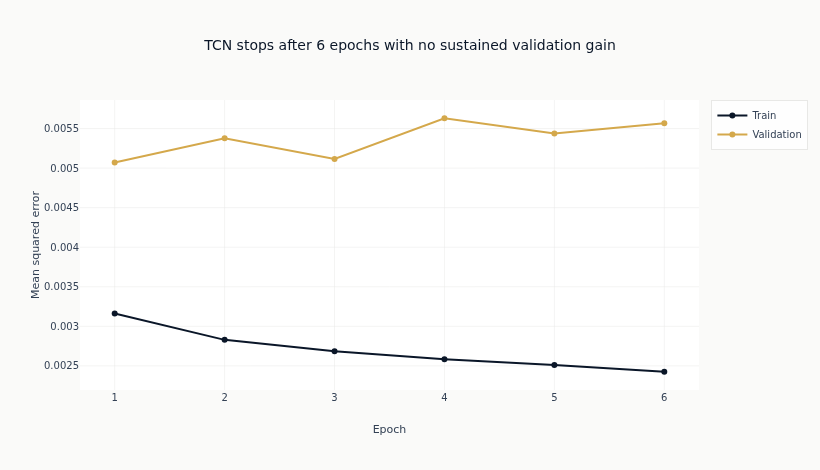

In [13]:
epochs_axis = list(range(1, len(history["train_loss"]) + 1))
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=epochs_axis,
        y=history["train_loss"],
        mode="lines+markers",
        name="Train",
        line_color=COLORS["blue"],
    )
)
fig.add_trace(
    go.Scatter(
        x=epochs_axis,
        y=history["val_loss"],
        mode="lines+markers",
        name="Validation",
        line_color=COLORS["amber"],
    )
)
fig.update_layout(
    title=f"TCN stops after {len(epochs_axis)} epochs with no sustained validation gain",
    xaxis_title="Epoch",
    yaxis_title="Mean squared error",
    width=820,
    height=470,
)
fig.show()

## Evaluate on Test Set

In [14]:
model.eval()
with torch.no_grad():
    X_test_t = torch.FloatTensor(X_test).to(DEVICE)
    y_pred = model(X_test_t).cpu().numpy()

test_mse = np.mean((y_pred - y_test) ** 2)
test_ic = cross_sectional_ic_mean(y_test, y_pred, test_dates, test_symbols)

print("\nTCN Test Results:")
print(f"  MSE: {test_mse:.6f}")
print(f"  Spearman IC: {test_ic:.4f}")


TCN Test Results:
  MSE: 0.003496
  Spearman IC: 0.0023


## Ridge Baseline Comparison

In [15]:
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_ridge_pred = ridge.predict(X_test_scaled)

ridge_mse = np.mean((y_ridge_pred - y_test) ** 2)
ridge_ic = cross_sectional_ic_mean(y_test, y_ridge_pred, test_dates, test_symbols)
zero_mse = float(np.mean(y_test**2))

print("\nRidge Baseline Results:")
print(f"  MSE: {ridge_mse:.6f}")
print(f"  Spearman IC: {ridge_ic:.4f}")


Ridge Baseline Results:
  MSE: 0.003457
  Spearman IC: 0.0170


## Summary

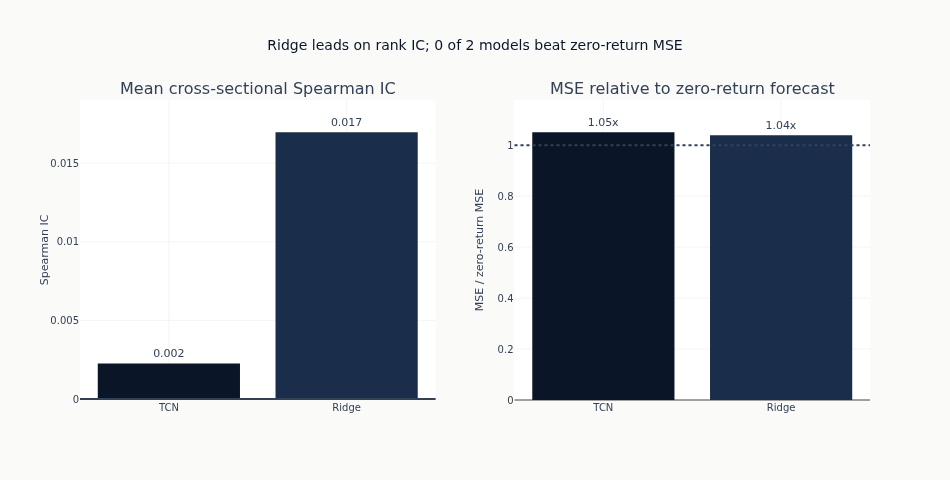

In [16]:
model_names = ["TCN", "Ridge"]
ic_values = [test_ic, ridge_ic]
mse_ratios = [test_mse / zero_mse, ridge_mse / zero_mse]
bar_palette = {"TCN": COLORS["blue"], "Ridge": COLORS["slate"]}

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("Mean cross-sectional Spearman IC", "MSE relative to zero-return forecast"),
)
for model_name, ic_value, mse_ratio in zip(model_names, ic_values, mse_ratios, strict=True):
    fig.add_trace(
        go.Bar(
            x=[model_name],
            y=[ic_value],
            name=model_name,
            marker_color=bar_palette[model_name],
            text=[f"{ic_value:.3f}"],
            textposition="outside",
            showlegend=False,
        ),
        row=1,
        col=1,
    )
    fig.add_trace(
        go.Bar(
            x=[model_name],
            y=[mse_ratio],
            name=model_name,
            marker_color=bar_palette[model_name],
            text=[f"{mse_ratio:.2f}x"],
            textposition="outside",
            showlegend=False,
        ),
        row=1,
        col=2,
    )

ic_leader = model_names[int(np.argmax(ic_values))]
mse_winners = sum(ratio < 1 for ratio in mse_ratios)
fig.add_hline(y=0, line_color=COLORS["neutral"], row=1, col=1)
fig.add_hline(y=1, line_dash="dot", line_color=COLORS["neutral"], row=1, col=2)
fig.update_layout(
    title=f"{ic_leader} leads on rank IC; {mse_winners} of 2 models beat zero-return MSE",
    width=950,
    height=480,
)
fig.update_yaxes(title_text="Spearman IC", row=1, col=1)
fig.update_yaxes(title_text="MSE / zero-return MSE", row=1, col=2)
fig.show()

The left panel measures cross-sectional ranking, while the right panel asks
whether either fitted model improves squared error over predicting zero. These
are distinct questions. This purged single split demonstrates the architecture;
it does not establish a stable model ranking. Section 13.9 supplies the
walk-forward comparison across datasets.

## Key Takeaways

1. **Causal convolutions prevent lookahead bias**: Left-padding ensures
   each output depends only on past and present inputs
2. **Exponential dilations are efficient**: Dilations of 1, 2, 4, 8 cover
   a receptive field of 61 timesteps with only 4 layers
3. **Fully parallelizable**: Unlike LSTMs, all timesteps are processed
   simultaneously during both training and inference
4. **Fixed receptive field**: The maximum lookback is determined at design
   time by the dilation schedule -- unlike attention, which adapts dynamically
5. **Reference architecture matters**: Weight normalization, channel-wise
   dropout, and the final causal state preserve the TCN block's intended
   inductive bias without mixing batch statistics

Deterministic PyTorch algorithms and a fixed cuBLAS workspace make repeated
executions reproducible on the same software and GPU stack; another environment
may still produce small floating-point differences.

**Next**: See `06_tsmixer` for an MLP-only alternative that achieves
competitive results without convolutions or attention.
**Book**: Section 13.6 compares TCN with other non-attention architectures.